Points generated:
[[0.77395605 0.43887844]
 [0.85859792 0.69736803]
 [0.09417735 0.97562235]
 [0.7611397  0.78606431]
 [0.12811363 0.45038594]
 [0.37079802 0.92676499]
 [0.64386512 0.82276161]
 [0.4434142  0.22723872]
 [0.55458479 0.06381726]
 [0.82763117 0.6316644 ]]
Shape of X: (10, 2)


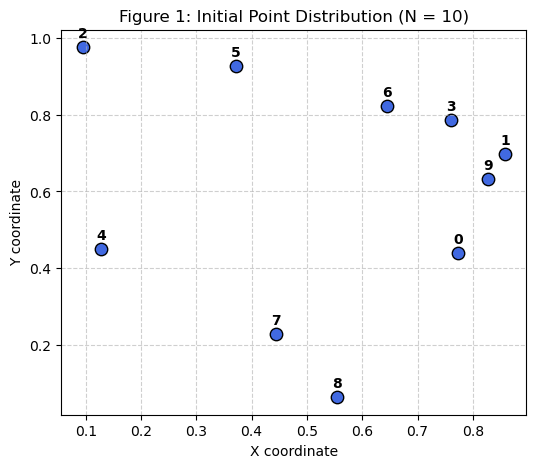

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Fixed seed so results are reproducible
rng = np.random.default_rng(seed=42)
X = rng.random((10, 2))          # 10 random points in the unit square

print("Points generated:")
print(X)
print("Shape of X:", X.shape)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], color="royalblue", s=80, edgecolors="black")
for i, (x, y) in enumerate(X):
    plt.annotate(str(i), (x, y), textcoords="offset points",
                 xytext=(0, 7), ha="center", fontweight="bold")
plt.title("Figure 1: Initial Point Distribution (N = 10)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [4]:
# Single-line version using broadcasting with np.newaxis
dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)
print("Distance matrix shape:", dist_sq.shape)

Distance matrix shape: (10, 10)


In [6]:
# Same computation broken into three steps
diff    = X[:, np.newaxis, :] - X[np.newaxis, :, :]   # (a) coordinate differences
sq_diff = diff ** 2                                    # (b) squared differences
dist_sq = np.sum(sq_diff, axis=-1)                     # (c) summed squared distances

print("(a) Shape of coordinate differences:", diff.shape)
print("(b) Shape of squared differences:   ", sq_diff.shape)
print("(c) Shape of distance matrix:       ", dist_sq.shape)

(a) Shape of coordinate differences: (10, 10, 2)
(b) Shape of squared differences:    (10, 10, 2)
(c) Shape of distance matrix:        (10, 10)


In [8]:
diagonal = np.diag(dist_sq)
print("Diagonal values:", diagonal)
print("All diagonal elements zero?", np.allclose(diagonal, 0))

Diagonal values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All diagonal elements zero? True


In [10]:
# (a) Full sort of every row
nearest = np.argsort(dist_sq, axis=1)
print("Full sort indices:\n", nearest)
print("\nFirst column:", nearest[:, 0])
print("First column equals 0..9?", np.array_equal(nearest[:, 0], np.arange(10)))

Full sort indices:
 [[0 9 1 3 7 6 8 5 4 2]
 [1 9 3 6 0 5 7 8 4 2]
 [2 5 4 6 3 9 1 7 0 8]
 [3 6 1 9 0 5 7 2 4 8]
 [4 7 2 5 8 6 0 3 9 1]
 [5 2 6 3 4 1 9 0 7 8]
 [6 3 1 9 5 0 2 7 4 8]
 [7 8 4 0 9 1 6 3 5 2]
 [8 7 0 4 9 1 3 6 5 2]
 [9 1 3 0 6 5 7 8 4 2]]

First column: [0 1 2 3 4 5 6 7 8 9]
First column equals 0..9? True


In [12]:
# (b) K = 2 using np.argpartition
K = 2

# kth=K puts the K+1 smallest values in the first K+1 columns (unsorted)
nearest_partition = np.argpartition(dist_sq, K, axis=1)
print("K+1 smallest indices per row (self included, unsorted):")
print(nearest_partition[:, :K + 1])

# Cross-check against the full sort (compare as sets, since argpartition does not order)
same = all(set(nearest_partition[i, :K + 1]) == set(nearest[i, :K + 1]) for i in range(10))
print("Matches full sort?", same)

K+1 smallest indices per row (self included, unsorted):
[[0 9 1]
 [1 9 3]
 [2 5 4]
 [3 6 1]
 [4 7 2]
 [5 2 6]
 [6 3 1]
 [7 8 4]
 [8 7 0]
 [9 1 3]]
Matches full sort? True


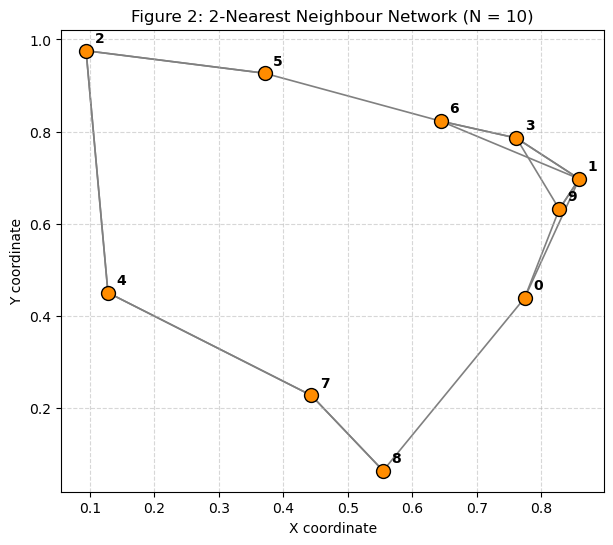

Lines connected to each point: [3 4 2 3 2 2 3 2 2 3]


In [14]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color="darkorange", s=100, zorder=3, edgecolors="black")

# Draw a line from each point to its K nearest neighbours
degree = np.zeros(10, dtype=int)          # how many lines touch each point
edges = set()
for i in range(X.shape[0]):
    for j in nearest_partition[i, :K + 1]:
        if j != i:                        # skip the point itself
            edges.add(tuple(sorted((i, j))))
            plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]],
                     color="gray", linewidth=1.2, zorder=1)

for a, b in edges:
    degree[a] += 1
    degree[b] += 1

for i, (x, y) in enumerate(X):
    plt.annotate(str(i), (x, y), textcoords="offset points",
                 xytext=(6, 6), fontweight="bold")

plt.title("Figure 2: 2-Nearest Neighbour Network (N = 10)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("Lines connected to each point:", degree)

In [16]:
import numpy as np
def loop_knn(points, k=2):
    """Loop version: computes and sorts the distances of ONE point at a time."""
    n = points.shape[0]
    neighbors = np.empty((n, k), dtype=int)
    for i in range(n):
        d = np.sum((points - points[i]) ** 2, axis=1)   # distances from point i
        neighbors[i] = np.argsort(d)[1:k + 1]           # skip self at index 0
    return neighbors


def vectorized_knn(points, k=2):
    """Vectorized version: all distances at once with broadcasting."""
    d = np.sum((points[:, np.newaxis, :] - points[np.newaxis, :, :]) ** 2, axis=-1)
    return np.argsort(d, axis=1)[:, 1:k + 1]


# Both versions must give identical answers
test = np.random.default_rng(0).random((100, 2))
print("Same result?", np.array_equal(loop_knn(test), vectorized_knn(test)))

Same result? True


In [18]:
pts_100  = np.random.default_rng(0).random((100, 2))
pts_1000 = np.random.default_rng(0).random((1000, 2))
pts_5000 = np.random.default_rng(0).random((5000, 2))

In [20]:
print("N = 100")
%timeit loop_knn(pts_100)
%timeit vectorized_knn(pts_100)

N = 100
3.87 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.45 ms ± 128 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [21]:
print("N = 1000")
%timeit loop_knn(pts_1000)
%timeit vectorized_knn(pts_1000)

N = 1000
234 ms ± 26.3 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
203 ms ± 18.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [23]:
print("N = 5000  (the vectorized version builds a 5000 x 5000 x 2 array, about 400 MB)")
%timeit loop_knn(pts_5000)
%timeit vectorized_knn(pts_5000)

N = 5000  (the vectorized version builds a 5000 x 5000 x 2 array, about 400 MB)
4.68 s ± 191 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
5.48 s ± 236 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [26]:
from sklearn.neighbors import KDTree

pts = np.random.default_rng(0).random((1000, 2))

def kdtree_knn(points, k=2):
    tree = KDTree(points)
    _, idx = tree.query(points, k=k + 1)   # k+1 because the point is its own neighbour
    return idx[:, 1:]

# Compare results
print("Same neighbours as NumPy?", np.array_equal(kdtree_knn(pts), vectorized_knn(pts)))

Same neighbours as NumPy? True


In [28]:
%timeit vectorized_knn(pts)
%timeit kdtree_knn(pts)

195 ms ± 21.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.27 ms ± 845 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
